# 用 desilike 计算 DES Y3 weak lensing 与 likelihood

这是一份使用教程，不依赖外部 DES 参考仓库。使用本分支的 `refactor-jax` API 和包内 DES Y3 数据，按顺序运行即可。

流程：**宇宙学参数 → theory → P(k,z) → Cℓ → 关联函数 → likelihood → 参数更新 → JIT / 梯度**。

采用 NLA、Legendre 变换和非 Limber 星系聚类；这里不包含 TATT。DES 3×2pt 包含宇宙剪切、星系–剪切和星系聚类，不能把三个部分都理解成单独的 cosmic shear。

最简用法是：
```python
from desilike import build
from desilike.likelihoods.weak_lensing import BaseDESY3Likelihood

likelihood = BaseDESY3Likelihood(use_sr=True)
loglike = build(likelihood)
print(loglike({'omega_cdm': 0.12}))
```
下面逐步解释如何控制配置、取得理论结果、画图和计算 χ²。

## 0. 环境与数据

在所用 Python 环境中安装这个分支及兼容依赖：
```sh
python -m pip install --upgrade 'cosmoprimo @ git+https://github.com/cosmodesi/cosmoprimo' 'lsstypes @ git+https://github.com/adematti/lsstypes'
python -m pip install -e '.[weak-lensing]'
```
Jupyter 绘图还需要 matplotlib、pandas。当前完整计算图已验证 JAX 0.6.2；升级依赖后请重启 kernel。下方可选路径只用于选择本机隔离的依赖版本；正常安装后无需设置。不修改全局安装、不屏蔽 JAX。

In [1]:
from pathlib import Path
import os
import sys

# Notebook 放在 checkout 时，优先导入当前 checkout。
root = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "desilike" / "__init__.py").is_file()
    ),
    None,
)
if root is not None:
    sys.path.insert(0, str(root))

# 可选：显式指定兼容的依赖源码目录。后备路径仅用于当前机器，其他机器自动忽略。
for variable, fallback in [
    ("DESILIKE_LSSTYPES_PATH", "/private/tmp/desilike-refactor-lsstypes"),
    ("DESILIKE_COSMOPRIMO_PATH", "/private/tmp/desilike-refactor-cosmoprimo"),
]:
    candidate = Path(os.environ.get(variable, fallback)).expanduser()
    if candidate.is_dir():
        sys.path.insert(0, str(candidate))

for name in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(name, "4")

import cosmoprimo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from IPython.display import display
from desilike import build
from desilike.theories.primordial_cosmology import CosmoprimoCosmology
from desilike.theories.weak_lensing import DESWeakLensing3x2pt
from desilike.likelihoods.weak_lensing import BaseDESY3Likelihood
from desilike.theories.weak_lensing.data import resolve_data_dir

jax.config.update("jax_enable_x64", True)
print("Python:", sys.executable)
print("JAX:", jax.__version__, "x64:", jax.config.jax_enable_x64)
print("Bundled DES data:", resolve_data_dir())


Python: /opt/anaconda3/bin/python
JAX: 0.6.2 x64: True
Bundled DES data: /Users/illyasviel/Desktop/project/desilike/desilike/theories/weak_lensing/des3


默认数据目录相对包位置解析，移动 desilike 后无需修改数据路径。

自定义数据可在构建之前这样指定：
```python
theory = DESWeakLensing3x2pt(data_dir="~/data/des-y3")
likelihood = BaseDESY3Likelihood(theory=theory)  # 自动沿用 theory 的目录
```
后面的可执行示例均使用包内数据。

## 1. 设置宇宙学

`omega_b`、`omega_cdm` 是 Ωh²；`h = H0/100`；`logA = ln(10¹⁰ As)`；`n_s` 为谱指数，`tau_reio` 为再电离光深。

用公开的 `propose_params()` 取得参数集合，再修改初值，可以保留已有参数元数据。这里设置值不等于设置先验；likelihood 和 posterior 也不是一回事。

In [2]:
lcdm = dict(
    h=0.6736, omega_b=0.02237, omega_cdm=0.12, logA=3.036394, n_s=0.9649, tau_reio=0.0544
)
fixed_cosmology = dict(m_ncdm=0.06, N_eff=3.046, Omega_k=0.0, w0_fld=-1.0, wa_fld=0.0)

cosmo_params = CosmoprimoCosmology.propose_params(fiducial="DESI")
for name, value in {**lcdm, **fixed_cosmology}.items():
    cosmo_params.set(cosmo_params[name].clone(value=value))

precision = {
    "calc_params": {
        "non_linear": "takahashi",
        "kmax_pk": 150.0,
        "z_pk": np.linspace(0.0, 3.0, 100),
    }
}
cosmo = CosmoprimoCosmology(engine="camb", params=cosmo_params, precision=precision)
display(pd.Series({**lcdm, **fixed_cosmology}, name="value"))


h            0.673600
omega_b      0.022370
omega_cdm    0.120000
logA         3.036394
n_s          0.964900
tau_reio     0.054400
m_ncdm       0.060000
N_eff        3.046000
Omega_k      0.000000
w0_fld      -1.000000
wa_fld       0.000000
Name: value, dtype: float64

## 2. 创建 theory，再 build

- `Weyl=True`：使用 Weyl 势及其与密度的交叉谱构造透镜项；`False` 使用密度表示。
- `Limber=False`：星系聚类保留参考实现的低 ℓ 非 Limber 修正；并不是所有投影都使用非 Limber。
- `ia_model="NLA"`：内禀排列模型。
- `fourier="legendre"`：将 Cℓ 转换成按角度 bin 平均的关联函数。

`build()` 连接依赖、登记功率谱/背景需求，并进行初始化。随后通过返回的函数更新参数。不要使用旧接口 `theory.calculate()` 或 `theory(omega_cdm=...)`。

这里显式返回数组字典：这样普通调用和 JIT 都可以直接使用函数返回值，不依赖 JIT 期间对 Python 对象属性的修改。

In [3]:
theory = DESWeakLensing3x2pt(
    cosmo=cosmo, Weyl=True, Limber=False, ia_model="NLA", fourier="legendre"
)


def theory_output():
    return {
        name: getattr(theory, name)
        for name in (
            "ell",
            "cl_xip",
            "cl_xim",
            "cl_gammat",
            "cl_wtheta",
            "xip",
            "xim",
            "gammat",
            "wtheta",
        )
    }


theory_fn = build(theory, output=theory_output)
# 保存完整基准参数。后续比较都从这个点出发，避免上一次更新影响缺省值。
base_point = {p.name: np.asarray(p.value).copy() for p in theory_fn.params}
baseline = jax.tree_util.tree_map(np.asarray, theory_fn(base_point))

print("ell grid:", baseline["ell"].shape)
for name in ("cl_xip", "cl_xim", "cl_gammat", "cl_wtheta", "xip", "xim", "gammat", "wtheta"):
    print(name, baseline[name].shape)
    assert np.isfinite(baseline[name]).all()


ell grid: (40001,)
cl_xip (4, 4, 40001)
cl_xim (4, 4, 40001)
cl_gammat (6, 4, 40001)
cl_wtheta (6, 6, 40001)
xip (4, 4, 20)
xim (4, 4, 20)
gammat (6, 4, 20)
wtheta (6, 6, 20)


数组顺序为 **[bin1, bin2, ℓ 或 θ]**，Python 下标从 0 开始：`gammat[0, 1]` 对应 lens bin 1、source bin 2。未计算的 bin pair 用零填充；读取 pair 列表可以避免误用。

`cl_xip` / `cl_xim` 在当前 NLA 设置中来自同一个剪切 E-mode 谱，但对应的 bin mask 可不同；ξ₊ / ξ₋ 的变换核不同，因此关联函数不同。当前 shear calibration `DES_m*` 应用于关联函数，而不是 `cl_*` 输出。

In [4]:
for name, pairs in theory.bin_pairs.items():
    print(name, "1-based bin pairs:", [(i + 1, j + 1) for i, j in pairs])


xip 1-based bin pairs: [(1, 1), (1, 2), (1, 3), (1, 4), (2, 2), (2, 3), (2, 4), (3, 3), (3, 4), (4, 4)]
xim 1-based bin pairs: [(1, 1), (1, 2), (1, 3), (1, 4), (2, 2), (2, 3), (2, 4), (3, 3), (3, 4), (4, 4)]
gammat 1-based bin pairs: [(1, 1), (1, 2), (1, 3), (1, 4), (2, 1), (2, 2), (2, 3), (2, 4), (3, 1), (3, 2), (3, 3), (3, 4), (4, 1), (4, 2), (4, 3), (4, 4), (5, 1), (5, 2), (5, 3), (5, 4), (6, 1), (6, 2), (6, 3), (6, 4)]
wtheta 1-based bin pairs: [(1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6)]


## 3. 三维物质功率谱 P(k,z)

P(k,z) 是投影到 Cℓ 之前的三维谱。这里读取 theory 已经向 cosmology 注册的网格，**不额外调用 CAMB**。

cosmoprimo 的 k 单位为 h/Mpc，P 单位为 (Mpc/h)³。返回数组为 `[z, k]`。物理单位转换是 `k_phys = h*k`、`P_phys = P/h**3`。

`get()` 读取的是已登记坐标；需要新的任意网格时，应在 build 前注册 requirements，而不是把未登记的 k/z 直接传给 get。

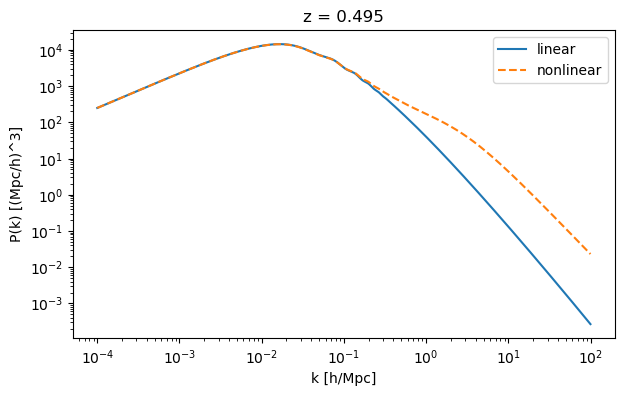

In [5]:
k = theory.kernels.k
z_grid = theory.kernels.z_pk
pk_linear = np.asarray(
    cosmo.get(
        "fourier.pk",
        of="delta_m",
        z=z_grid,
        k=k,
        non_linear=False,
        extrap_kmax_physical=8000.0,
    )
)
pk_nonlinear = np.asarray(
    cosmo.get(
        "fourier.pk", of="delta_m", z=z_grid, k=k, non_linear=True, extrap_kmax_physical=8000.0
    )
)

iz = np.argmin(np.abs(z_grid - 0.5))
plot_k = (k >= 1e-4) & (k <= 100.0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(k[plot_k], pk_linear[iz, plot_k], label="linear")
ax.loglog(k[plot_k], pk_nonlinear[iz, plot_k], "--", label="nonlinear")
ax.set(xlabel="k [h/Mpc]", ylabel="P(k) [(Mpc/h)^3]", title=f"z = {z_grid[iz]:.3f}")
ax.legend()
plt.show()
assert pk_linear.shape == (len(z_grid), len(k))


## 4. 角功率谱 Cℓ

`cl_xip` 是剪切谱，`cl_gammat` 是星系–剪切交叉谱，`cl_wtheta` 是星系聚类谱。下图先展示各自的 (1,1) pair；更换 `i,j` 即可检查其他 pair。

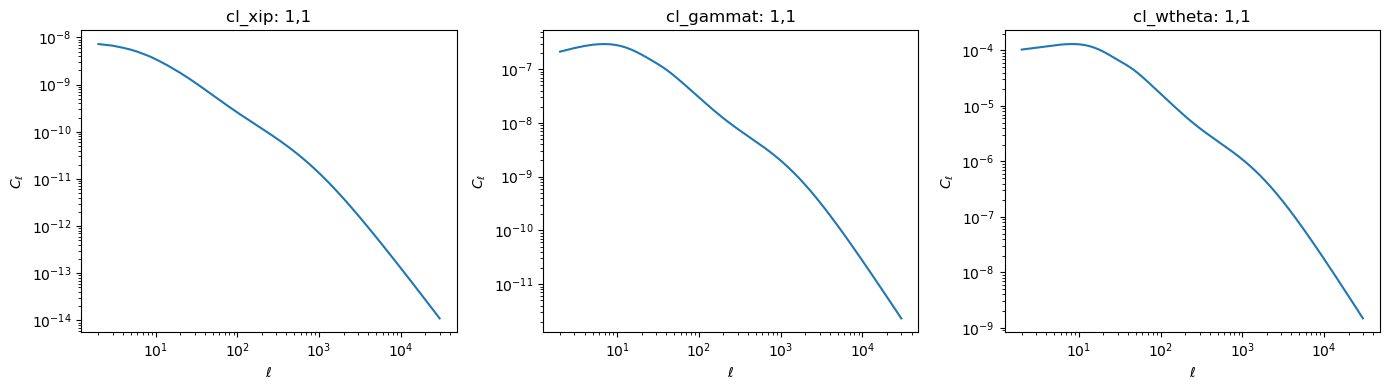

In [6]:
ell = baseline["ell"]
i, j = 0, 0
mask = (ell >= 2) & (ell <= 30000)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, ("cl_xip", "cl_gammat", "cl_wtheta")):
    ax.loglog(ell[mask], baseline[name][i, j, mask])
    ax.set(xlabel=r"$\ell$", ylabel=r"$C_\ell$", title=f"{name}: {i+1},{j+1}")
fig.tight_layout()
plt.show()


## 5. 关联函数 ξ₊、ξ₋、γₜ、w(θ)

理论已经使用 DES 的角度 bin 做了变换。下面读取相同的 θ 网格；单位为 arcmin。随后演示类似原 notebook 的 lens × source 绘图布局。

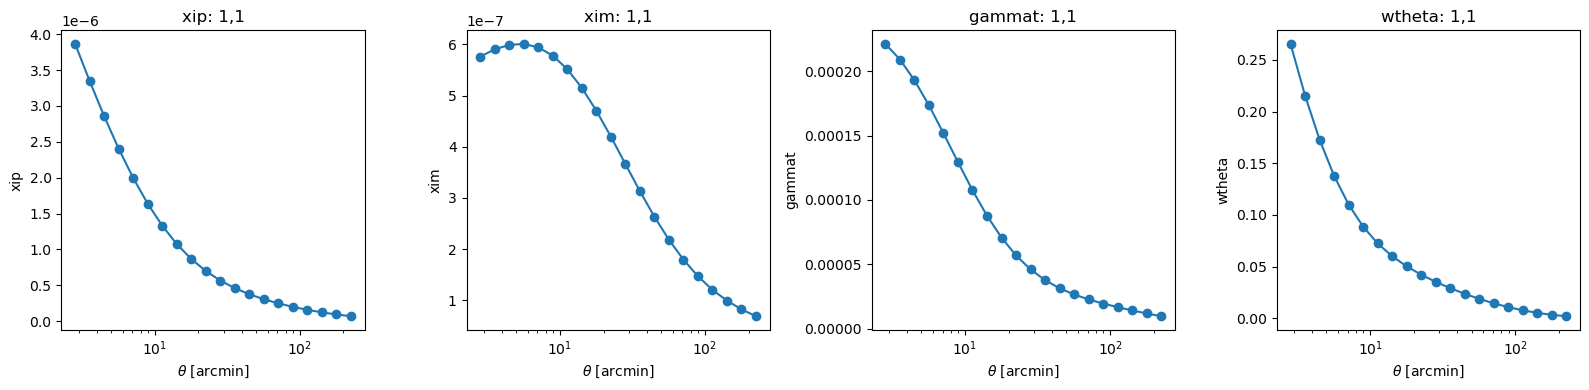

In [7]:
theta_bins = np.loadtxt(Path(theory.data_dir) / "DES_3YR_final_theta_bins.dat")[:, 2]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, name in zip(axes, ("xip", "xim", "gammat", "wtheta")):
    ax.semilogx(theta_bins, baseline[name][0, 0], "o-")
    ax.set(xlabel=r"$\theta$ [arcmin]", ylabel=name, title=f"{name}: 1,1")
fig.tight_layout()
plt.show()


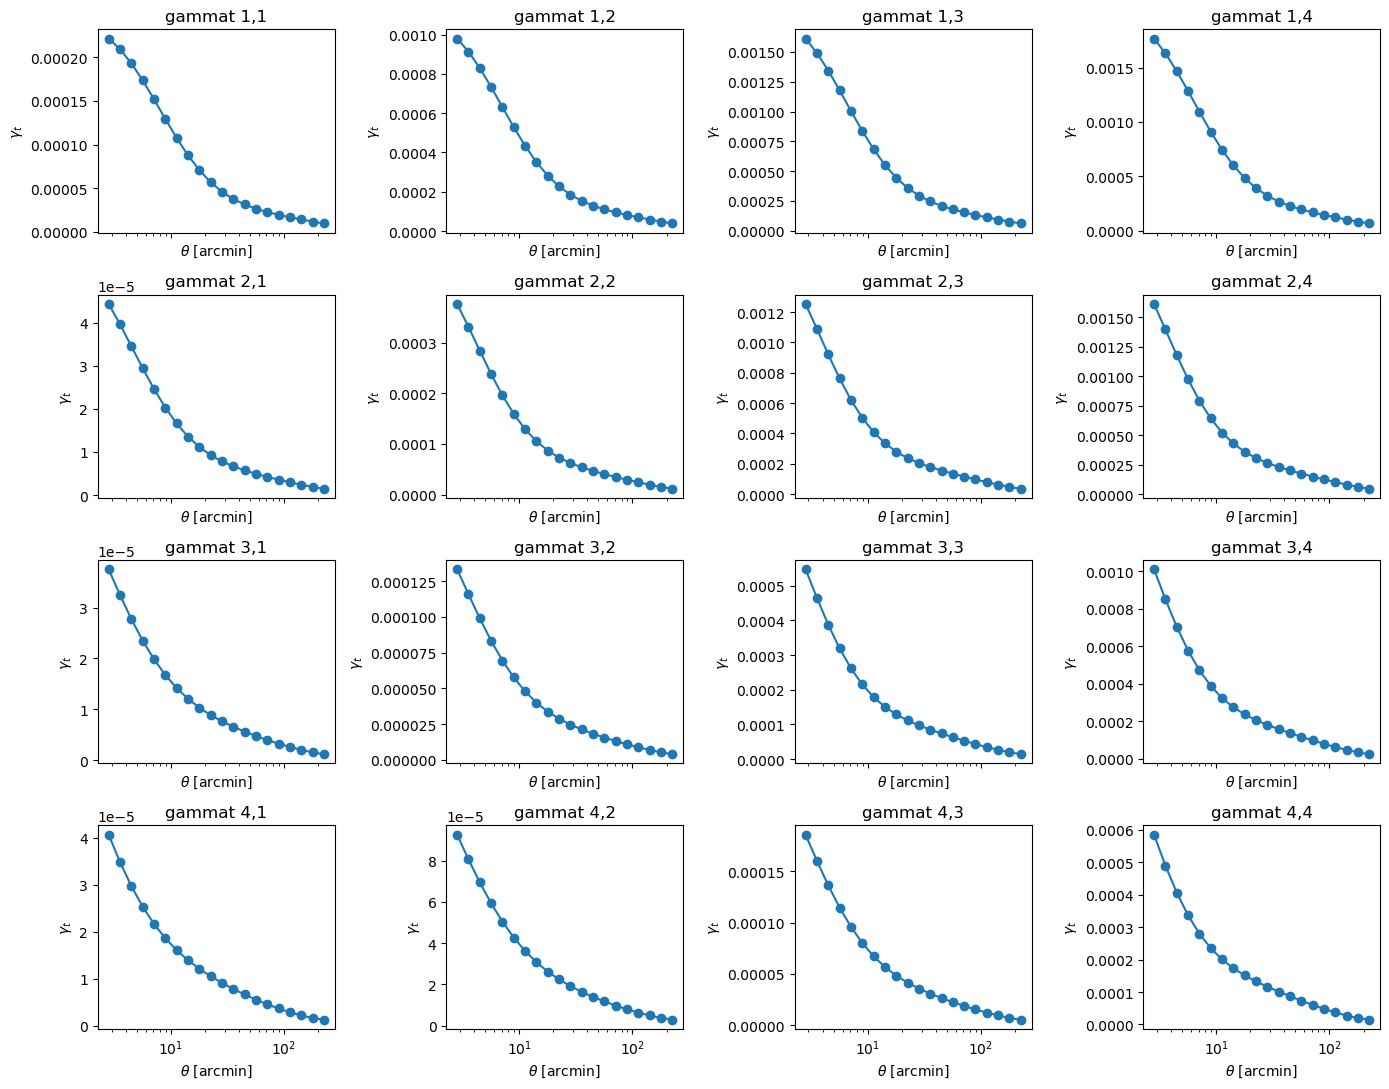

In [8]:
# 例：前 4 个 lens bins × 4 个 source bins 的 gamma_t。
fig, axes = plt.subplots(4, 4, figsize=(14, 11), sharex=True)
for i in range(4):
    for j in range(4):
        axes[i, j].semilogx(theta_bins, baseline["gammat"][i, j], "o-")
        axes[i, j].set_title(f"gammat {i+1},{j+1}")
        axes[i, j].set_xlabel(r"$\theta$ [arcmin]")
        axes[i, j].set_ylabel(r"$\gamma_t$")
fig.tight_layout()
plt.show()


## 6. 更新参数：无需重新创建 theory

宇宙学与 nuisance 参数都通过 build 返回的函数传入。下面只改变 `DES_m1`：这不改变宇宙学，CAMB 结果可以复用。改变 `h`、`omega_cdm` 等宇宙学参数会触发 CAMB 重算。

调用普通 pipeline 后缺省值可能反映最近一次计算，所以比较时明确使用 `{**base_point, ...}`，最后恢复基准点。

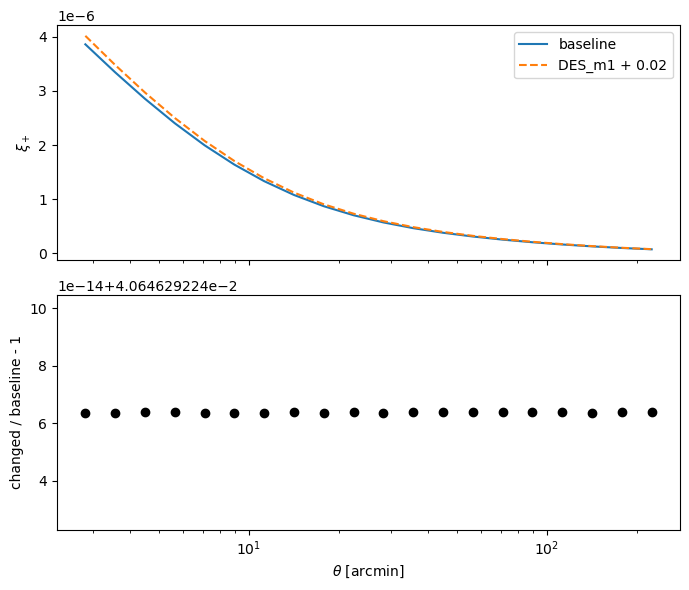

In [9]:
new_point = {**base_point, "DES_m1": float(base_point["DES_m1"]) + 0.02}
changed = jax.tree_util.tree_map(np.asarray, theory_fn(new_point))

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
axes[0].semilogx(theta_bins, baseline["xip"][0, 0], label="baseline")
axes[0].semilogx(theta_bins, changed["xip"][0, 0], "--", label="DES_m1 + 0.02")
axes[0].set_ylabel(r"$\xi_+$")
axes[0].legend()
axes[1].semilogx(theta_bins, changed["xip"][0, 0] / baseline["xip"][0, 0] - 1, "ko")
axes[1].set(xlabel=r"$\theta$ [arcmin]", ylabel="changed / baseline - 1")
fig.tight_layout()
plt.show()
expected = ((1 + float(new_point["DES_m1"])) / (1 + float(base_point["DES_m1"]))) ** 2
np.testing.assert_allclose(changed["xip"][0, 0], baseline["xip"][0, 0] * expected, rtol=1e-10)
_ = theory_fn(base_point)


## 7. 从 theory 构建 DES Y3 likelihood

`use_sr=True` 加入 shear-ratio 数据；`False` 只计算 3×2pt。点质量边缘化已经包含在默认 likelihood 中。

这里把已有 theory 交给 likelihood，使用同一套数据目录。构建 likelihood 后，后续统一使用新的 `loglike` 驱动整个图；不要继续使用构建前的旧 `theory_fn`。修改 `Weyl` / `Limber` / 数据目录属于结构配置，需要重新构建，不能作为浮点采样参数传入。

In [10]:
likelihood = BaseDESY3Likelihood(theory=theory, use_sr=True)
loglike = build(likelihood)
logL = float(loglike(base_point))
chi2_3x2pt = float(likelihood.chi2_3x2pt)
chi2_sr = float(likelihood.chi2_sr)
chi2_total = -2 * logL

display(
    pd.Series(
        {
            "log_likelihood": logL,
            "chi2_3x2pt": chi2_3x2pt,
            "chi2_shear_ratios": chi2_sr,
            "chi2_total": chi2_total,
        }
    )
)
np.testing.assert_allclose(chi2_total, chi2_3x2pt + chi2_sr, rtol=1e-12)
print("3x2pt 数据向量长度:", likelihood.data_vector.size)
print("theory 向量长度:", likelihood.flattheory.size)
print("likelihood data:", likelihood.data_dir)


log_likelihood      -382.787103
chi2_3x2pt           526.897265
chi2_shear_ratios    238.676941
chi2_total           765.574206
dtype: float64

3x2pt 数据向量长度: 256
theory 向量长度: 256
likelihood data: /Users/illyasviel/Desktop/project/desilike/desilike/theories/weak_lensing/des3


这里的返回值是 **log-likelihood**，不包含参数先验；本 DES 参考约定为 `logL = -χ²/2`，未增加协方差 log-determinant 项。不要把它直接解释为带先验的 log-posterior。

`data_vector` 与 `flattheory` 已应用 standard cuts，并采用相同顺序。不能直接把所有关联函数 flatten 后拿来代替它们。以下表格显示各项实际进入 likelihood 的数据点数。

In [11]:
names = ("xip", "xim", "gammat", "wtheta")
used = pd.DataFrame(likelihood.used_items, columns=["type", "bin1", "bin2", "theta_index"])
used["observable"] = [names[t] for t in used["type"]]
display(used.groupby("observable").size().rename("number of data points"))

residual = np.asarray(likelihood.flattheory) - likelihood.data_vector
manual_3x2pt = float(residual @ np.asarray(likelihood.precision) @ residual)
print("使用点质量边缘化后的 precision 手动计算 χ²:", manual_3x2pt)
np.testing.assert_allclose(manual_3x2pt, chi2_3x2pt, rtol=1e-9, atol=1e-7)


observable
gammat    105
wtheta     43
xim         3
xip       105
Name: number of data points, dtype: int64

使用点质量边缘化后的 precision 手动计算 χ²: 526.8972645548367


## 8. 用同一个 likelihood 比较不同宇宙学

下面只改变 `omega_cdm`，每个新值会重新计算 CAMB 与下游预测。这是参数响应演示，不是最优化或 posterior 推断。

In [12]:
rows = []
for omega_cdm in (0.118, 0.120, 0.122):
    point = {**base_point, "omega_cdm": omega_cdm}
    value = float(loglike(point))
    rows.append({"omega_cdm": omega_cdm, "logL": value, "chi2": -2 * value})
display(pd.DataFrame(rows))
_ = loglike(base_point)


,omega_cdm,logL,chi2
0,0.118,-370.130199,740.260397
1,0.120,-382.787103,765.574206
2,0.122,-397.093591,794.187182


## 9. JIT 与梯度

JAX eager 仍使用 JAX；`jax.jit(loglike)` 则把可编译部分作为一个计算图执行。首次调用包含编译；以后形状不变时通常复用编译结果。JIT 不保证整个流程比 NumPy 更快，尤其当每次更新都要重跑 CAMB。

NLA 核、投影和 likelihood 为原生 JAX；CAMB 和非 Limber FFTLog 通过外部节点接入。剪切校准可走原生 autodiff；经过外部节点的参数使用框架有限差分。这里检查 DES_m1 梯度，不声称所有宇宙学导数都是原生自动微分。

**JIT 下使用函数返回值**；需要额外输出时，在 build 的 `output=` 中显式返回，不通过读取对象属性推断刚才的 JIT 结果。

In [13]:
loglike_jit = jax.jit(loglike)
eager_value = float(loglike(base_point))
jit_value = float(loglike_jit(base_point))  # float() 同步等待设备结果
print("eager:", eager_value, "JIT:", jit_value, "difference:", jit_value - eager_value)
np.testing.assert_allclose(jit_value, eager_value, rtol=1e-9, atol=1e-5)

m0 = float(base_point["DES_m1"])


def loglike_at_m1(m1):
    return loglike({**base_point, "DES_m1": m1})


gradient = float(jax.grad(loglike_at_m1)(m0))
step = 1e-5
finite_difference = float(
    (
        loglike_jit({**base_point, "DES_m1": m0 + step})
        - loglike_jit({**base_point, "DES_m1": m0 - step})
    )
    / (2 * step)
)
print("d logL / d DES_m1:", gradient)
print("central difference:", finite_difference)
np.testing.assert_allclose(gradient, finite_difference, rtol=1e-4, atol=1e-4)
_ = loglike(base_point)


eager: -382.7871029943156 JIT: -382.7871029943138 difference: 1.8189894035458565e-12


d logL / d DES_m1: 171.92843602321997
central difference: 171.92843602629182


## 10. 切换 Weyl / shear ratios 的方式

这些是构建选项。使用新实例可以保留已有计算图，避免重复 build 同一个对象后继续调用旧 pipeline。下面给出另一个常用配置：关闭 Weyl，且不包含 shear ratios。

In [14]:
cosmo_density = CosmoprimoCosmology(
    engine="camb", params=[p.clone() for p in cosmo_params], precision=precision
)
theory_density = DESWeakLensing3x2pt(cosmo=cosmo_density, Weyl=False, Limber=False)
likelihood_density = BaseDESY3Likelihood(theory=theory_density, use_sr=False)
loglike_density = build(likelihood_density)
value_density = float(loglike_density(base_point))
print("Weyl=False, use_sr=False: logL =", value_density)
print("chi2_3x2pt =", float(likelihood_density.chi2_3x2pt))
assert float(likelihood_density.chi2_sr) == 0.0
np.testing.assert_allclose(-2 * value_density, float(likelihood_density.chi2_3x2pt))


Weyl=False, use_sr=False: logL = -263.4486024747754
chi2_3x2pt = 526.8972049495508


这段示例同时改变了 Weyl 和 shear-ratio 配置，因此不要把它和上一节的总 χ² 差异全部归因于 Weyl。若要比较 Weyl 开关的影响，两边应使用相同的 `use_sr`、数据选择和参数。

实际工作中：修改数值参数用 `pipeline({...})`；修改模型/数据配置用新实例再 `build()`。更完整的多宇宙学一致性检查、逐 bin-pair 相对差和运行时间测量见同目录的 `desilike_test.ipynb`。